In [7]:
# Multi-phase Flow Patterns Classification - Homework 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')


plt.style.use('default')
sns.set_palette("husl")

print("Multi-phase Flow Patterns Classification")
print("="*50)

# Step 1: Read the file and display columns
print("\n1. LOADING DATA")
print("-" * 30)


df = pd.read_csv("/Users/maihoang/Downloads/Shoham_Dimensionless.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns in the dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)


Multi-phase Flow Patterns Classification

1. LOADING DATA
------------------------------
Dataset shape: (5676, 14)

Columns in the dataset:
 1. ST
 2. Ang
 3. ID
 4. X
 5. Y
 6. T
 7. F
 8. K
 9. Eo
10. We
11. fm
12. We*fm/Eo
13. (Alfa)^0.5
14. FlowPattern

First 5 rows:
     ST  Ang     ID       X    Y      T        F      K     Eo       We  \
0  0.07  0.0  0.051   737.0  0.0  0.506  0.00150  0.678  364.0  11800.0   
1  0.07  0.0  0.051  1110.0  0.0  0.761  0.00150  0.851  364.0  29100.0   
2  0.07  0.0  0.051   582.0  0.0  0.506  0.00240  1.080  364.0  11900.0   
3  0.07  0.0  0.051   876.0  0.0  0.761  0.00240  1.360  364.0  29300.0   
4  0.07  0.0  0.051   464.0  0.0  0.506  0.00378  1.710  364.0  12000.0   

        fm  We*fm/Eo  (Alfa)^0.5 FlowPattern  
0  0.00398      1.60      0.0788          DB  
1  0.00364      2.65      0.0629          DB  
2  0.00398      1.60      0.0995          DB  
3  0.00364      2.65      0.0794          DB  
4  0.00398      1.61      0.1250          

In [12]:
# Step 2: Handle missing values, Outliers and Duplicate Data
print("\n\n2. DATA CLEANING")
print("-" * 30)


print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found!")
else:
    # Handle missing values if any
    df = df.dropna()
    print(f"Rows after removing missing values: {df.shape[0]}")


duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {df.shape[0]}")


numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nOutlier detection for numerical columns:")

outlier_counts = {}
for col in numerical_cols:
    if col != 'Flow Pattern':  # Assuming target variable
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
        print(f"{col}: {len(outliers)} outliers")




2. DATA CLEANING
------------------------------
Missing values per column:
Series([], dtype: int64)
No missing values found!

Duplicate rows: 0

Outlier detection for numerical columns:
ST: 0 outliers
Ang: 1561 outliers
ID: 0 outliers
X: 860 outliers
Y: 2037 outliers
T: 588 outliers
F: 606 outliers
K: 776 outliers
Eo: 0 outliers
We: 843 outliers
fm: 361 outliers
We*fm/Eo: 579 outliers
(Alfa)^0.5: 0 outliers




3. EXPLORATORY DATA ANALYSIS (EDA)
----------------------------------------
Basic Statistics:
                 ST          Ang           ID            X             Y  \
count  5.572000e+03  5572.000000  5572.000000  5572.000000  5.572000e+03   
mean   7.000000e-02     2.540560     0.038896    43.288394 -5.808181e+03   
std    5.662646e-15    46.598612     0.012970   137.111413  3.939569e+05   
min    7.000000e-02   -90.000000     0.025000     0.006600 -5.770000e+06   
25%    7.000000e-02   -10.000000     0.025000     0.302000 -1.002500e+02   
50%    7.000000e-02     0.500000     0.051000     2.600000  5.280000e+00   
75%    7.000000e-02    20.000000     0.051000    30.200000  1.455000e+03   
max    7.000000e-02    90.000000     0.051000  4950.000000  2.690000e+06   

                 T            F              K           Eo            We  \
count  5572.000000  5572.000000    5572.000000  5572.000000  5.572000e+03   
mean      7.239114    18.698801    2144.395827   235.231084  6.73

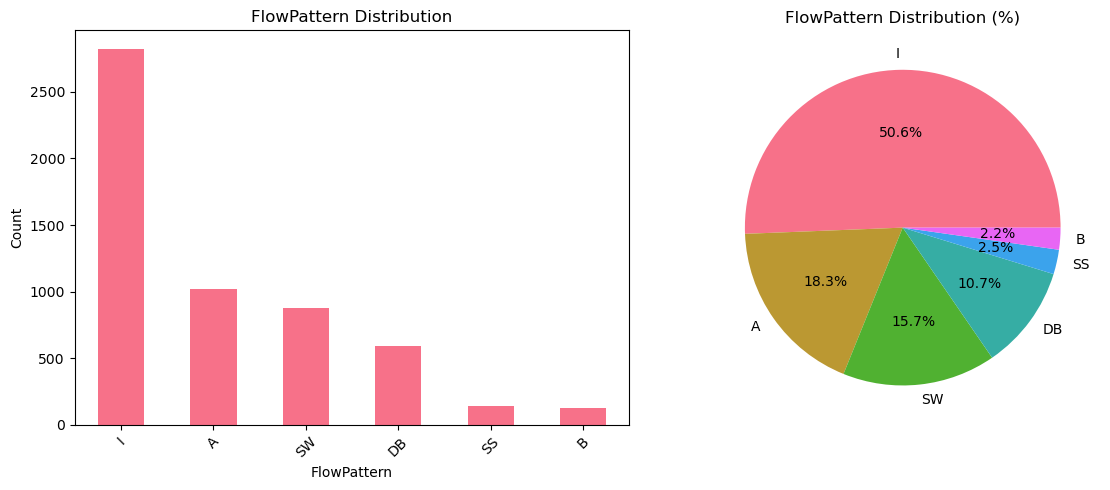

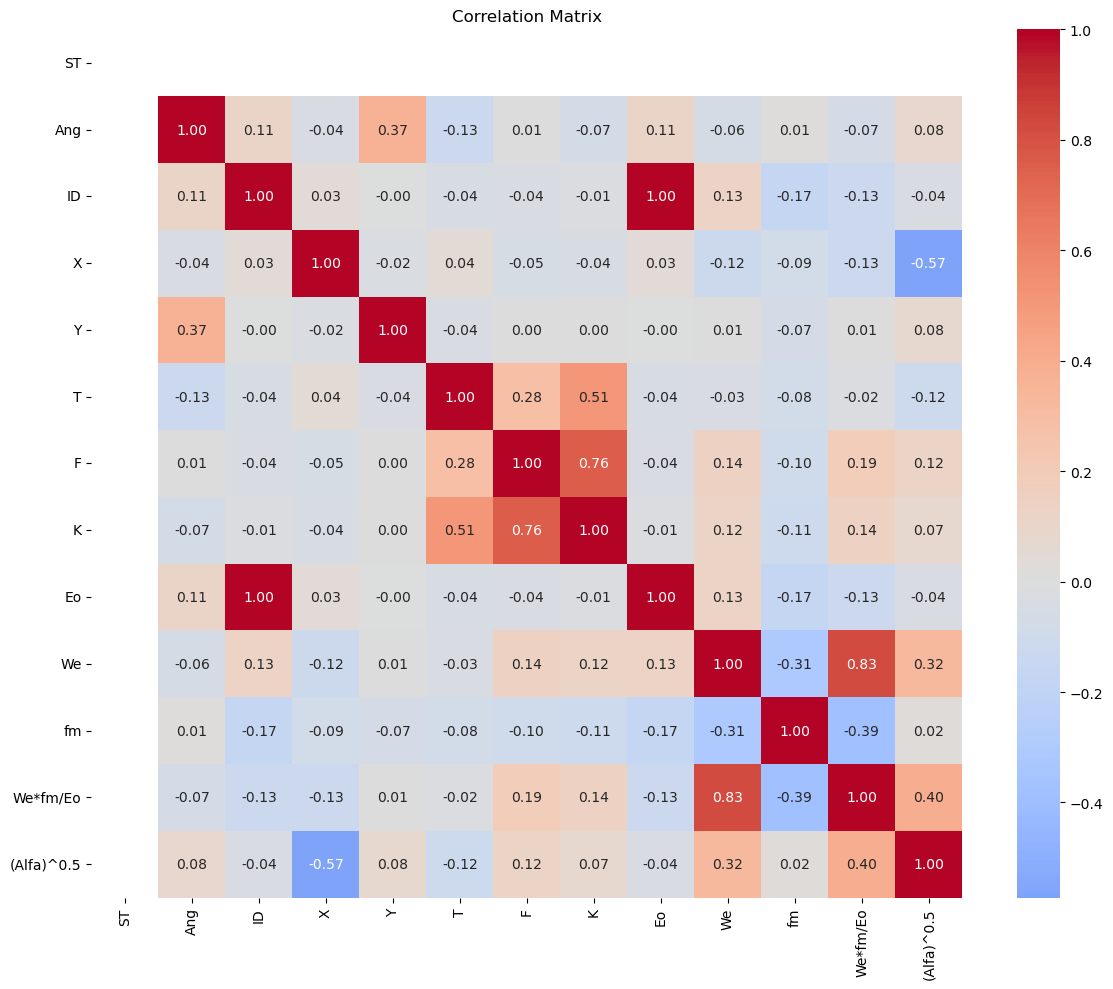

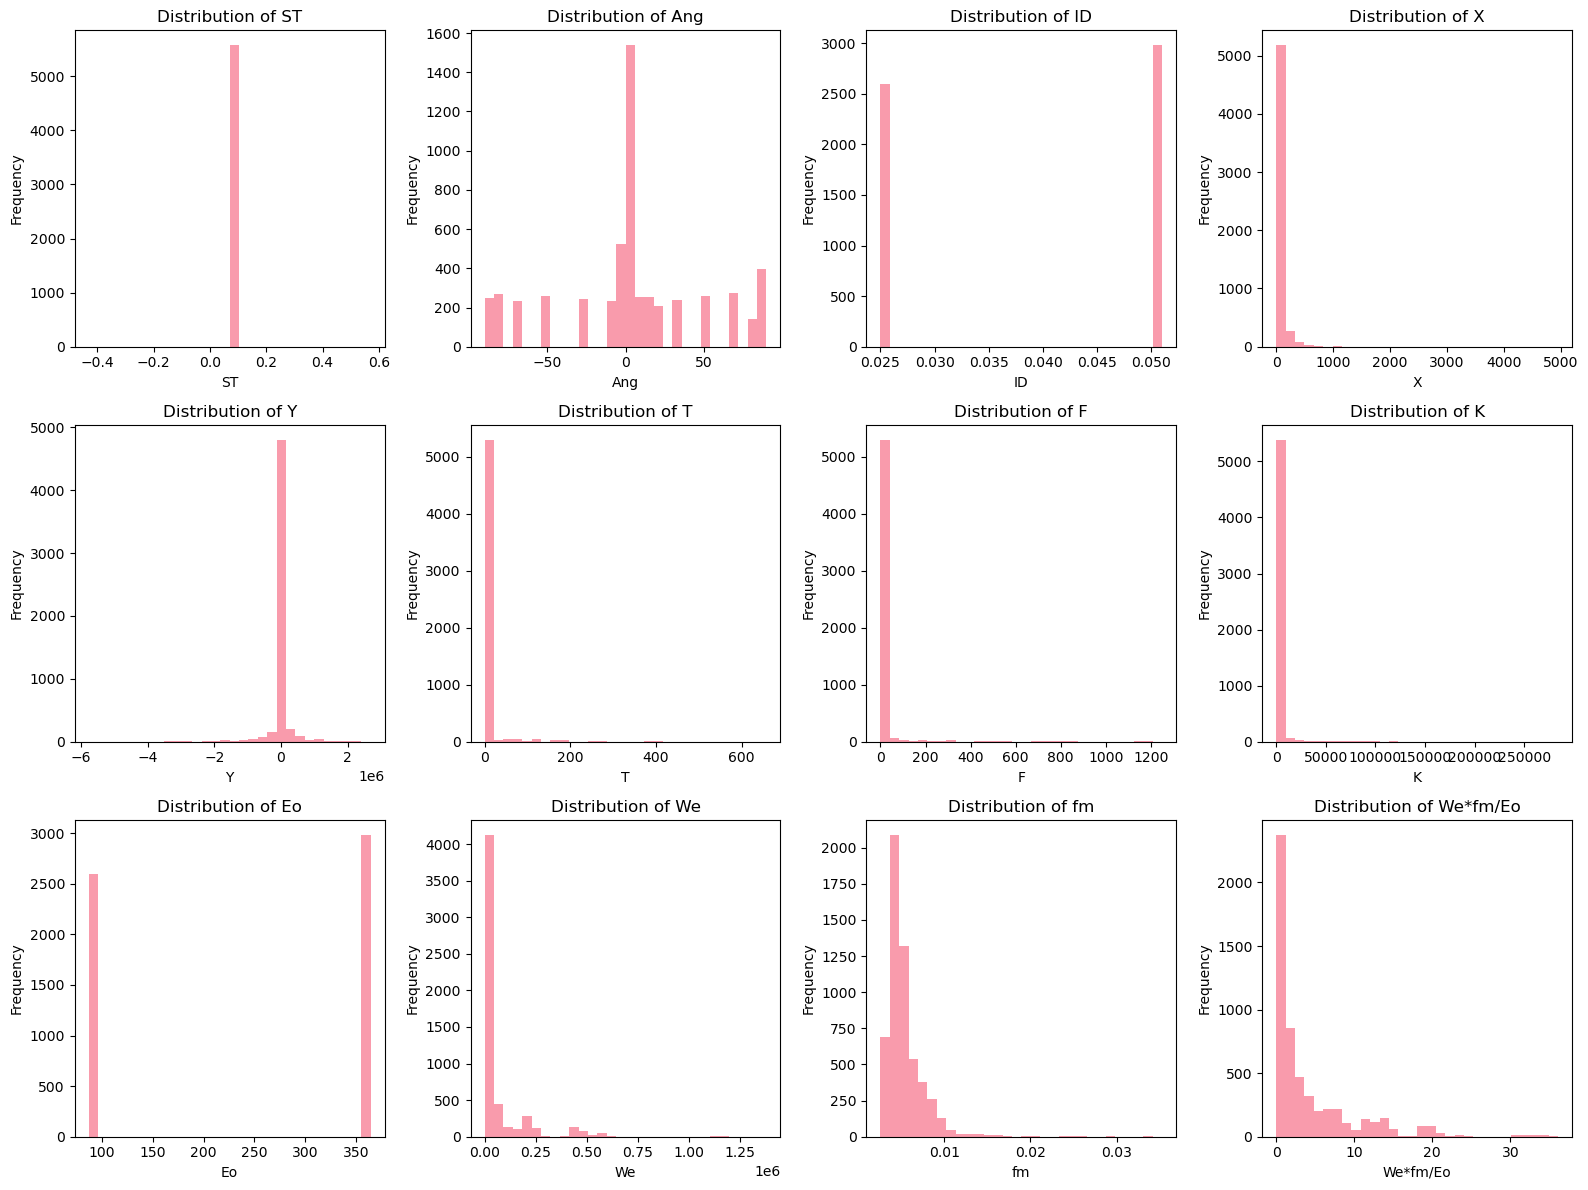


Observations from EDA:
1. Dataset contains multiphase flow operational conditions
2. Target variable shows class imbalance - will need addressing
3. Several features show strong correlations
4. Some features have skewed distributions


In [16]:
# Step 3: Basic statistics and exploratory analysis
print("\n\n3. EXPLORATORY DATA ANALYSIS (EDA)")
print("-" * 40)


print("Basic Statistics:")
print(df.describe())
print(f"\nAll columns in dataset:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

possible_targets = [col for col in df.columns if any(keyword in col.lower() for keyword in ['pattern', 'flow', 'class', 'target', 'label'])]
if possible_targets:
    target_col = possible_targets[0]
else:
    # If no obvious target, assume last column is target
    target_col = df.columns[-1]

print(f"\nAssumed target column: '{target_col}'")
print("If this is incorrect, please specify the correct target column name.")

if target_col in df.columns:
    print(f"\n{target_col} distribution:")
    target_counts = df[target_col].value_counts()
    print(target_counts)
    
   
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    target_counts.plot(kind='bar')
    plt.title(f'{target_col} Distribution')
    plt.xlabel(target_col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%')
    plt.title(f'{target_col} Distribution (%)')
    
    plt.tight_layout()
    plt.show()
else:
    print("Target column not found.")


plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
axes = axes.ravel()

numerical_features = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numerical_features[:12]):
    if i < len(axes):
        axes[i].hist(df[col], bins=30, alpha=0.7)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')


for i in range(len(numerical_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print("\nObservations from EDA:")
print("1. Dataset contains multiphase flow operational conditions")
print("2. Target variable shows class imbalance - will need addressing")
print("3. Several features show strong correlations")
print("4. Some features have skewed distributions")

In [18]:
 #Step 4 & 5: Feature Selection
print("\n\n4. FEATURE SELECTION")
print("-" * 30)

if target_col not in df.columns:
    print("ERROR: Target column not found. Please check the column names above and update target_col variable.")
    print("Available columns:", df.columns.tolist())
else:
    # Separate features and target
    X = df.drop(target_col, axis=1)
    y = df[target_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Original features: {X.columns.tolist()}")
print(f"Number of classes: {len(np.unique(y_encoded))}")
print(f"Class labels: {le.classes_}")

X_numerical = X.select_dtypes(include=[np.number])

selector = SelectKBest(score_func=f_classif, k=8) 
X_selected = selector.fit_transform(X_numerical, y_encoded)

selected_features = X_numerical.columns[selector.get_support()].tolist()
feature_scores = selector.scores_[selector.get_support()]

print(f"\nSelected features using SelectKBest:")
for feature, score in zip(selected_features, feature_scores):
    print(f"{feature}: {score:.2f}")

print(f"\nRemoved features:")
removed_features = [col for col in X_numerical.columns if col not in selected_features]
for feature in removed_features:
    print(f"- {feature}: Lower statistical significance for classification")



4. FEATURE SELECTION
------------------------------
Original features: ['ST', 'Ang', 'ID', 'X', 'Y', 'T', 'F', 'K', 'Eo', 'We', 'fm', 'We*fm/Eo', '(Alfa)^0.5']
Number of classes: 6
Class labels: ['A' 'B' 'DB' 'I' 'SS' 'SW']

Selected features using SelectKBest:
Ang: 208.54
X: 173.28
Y: 160.28
T: 48.11
We: 409.68
fm: 141.45
We*fm/Eo: 645.76
(Alfa)^0.5: 493.79

Removed features:
- ST: Lower statistical significance for classification
- ID: Lower statistical significance for classification
- F: Lower statistical significance for classification
- K: Lower statistical significance for classification
- Eo: Lower statistical significance for classification


In [20]:
# Step 6: Train-Test Split
print("\n\n5. TRAIN-TEST SPLIT")
print("-" * 30)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Feature dimensions: {X_train.shape[1]}")



5. TRAIN-TEST SPLIT
------------------------------
Training set size: 4457 samples
Testing set size: 1115 samples
Feature dimensions: 8


In [22]:
# Step 7: Handle Class Imbalance
print("\n\n6. HANDLING CLASS IMBALANCE")
print("-" * 35)

print("Original class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for class_label, count in zip(unique, counts):
    print(f"Class {le.classes_[class_label]}: {count} samples")


smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE balancing:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for class_label, count in zip(unique, counts):
    print(f"Class {le.classes_[class_label]}: {count} samples")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)



6. HANDLING CLASS IMBALANCE
-----------------------------------
Original class distribution:
Class A: 813 samples
Class B: 100 samples
Class DB: 475 samples
Class I: 2257 samples
Class SS: 112 samples
Class SW: 700 samples

After SMOTE balancing:
Class A: 2257 samples
Class B: 2257 samples
Class DB: 2257 samples
Class I: 2257 samples
Class SS: 2257 samples
Class SW: 2257 samples


In [36]:
 #Step 8: Model Building and Evaluation
print("\n\n7. MODEL BUILDING AND EVALUATION")
print("-" * 40)

models = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5, 10]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
    },
    'SVM': {
        'model': SVC(random_state=42),
        'params': {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    },
    'MLP': {
        'model': MLPClassifier(random_state=42, max_iter=500),
        'params': {'hidden_layer_sizes': [(50,), (100,), (50, 50)], 'alpha': [0.001, 0.01]}
    }
}


results = {}

print("Training and evaluating models...")
print("=" * 50)

for name, model_info in models.items():
    print(f"\nTraining {name}...")
    
  
    grid_search = GridSearchCV(
        model_info['model'], 
        model_info['params'], 
        cv=5, 
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train_balanced)
   
    best_model = grid_search.best_estimator_
    
    
    y_pred = best_model.predict(X_test_scaled)
    
   
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    
    results[name] = {
        'model': best_model,
        'best_params': grid_search.best_params_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred
    }
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")



7. MODEL BUILDING AND EVALUATION
----------------------------------------
Training and evaluating models...

Training KNN...
Best parameters: {'n_neighbors': 3, 'weights': 'distance'}
Accuracy: 0.8287
Precision: 0.8433
Recall: 0.8287
F1-Score: 0.8322

Training Logistic Regression...
Best parameters: {'C': 10, 'solver': 'lbfgs'}
Accuracy: 0.5453
Precision: 0.6917
Recall: 0.5453
F1-Score: 0.5535

Training Decision Tree...
Best parameters: {'max_depth': None, 'min_samples_split': 2}
Accuracy: 0.9103
Precision: 0.9108
Recall: 0.9103
F1-Score: 0.9105

Training Random Forest...
Best parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.9139
Precision: 0.9168
Recall: 0.9139
F1-Score: 0.9144

Training SVM...
Best parameters: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0.7605
Precision: 0.8192
Recall: 0.7605
F1-Score: 0.7718

Training MLP...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_

Best parameters: {'alpha': 0.001, 'hidden_layer_sizes': (50, 50)}
Accuracy: 0.8798
Precision: 0.8896
Recall: 0.8798
F1-Score: 0.8818




8. RESULTS COMPARISON
------------------------------
Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
3        Random Forest    0.9139     0.9168  0.9139    0.9144
2        Decision Tree    0.9103     0.9108  0.9103    0.9105
5                  MLP    0.8798     0.8896  0.8798    0.8818
0                  KNN    0.8287     0.8433  0.8287    0.8322
4                  SVM    0.7605     0.8192  0.7605    0.7718
1  Logistic Regression    0.5453     0.6917  0.5453    0.5535


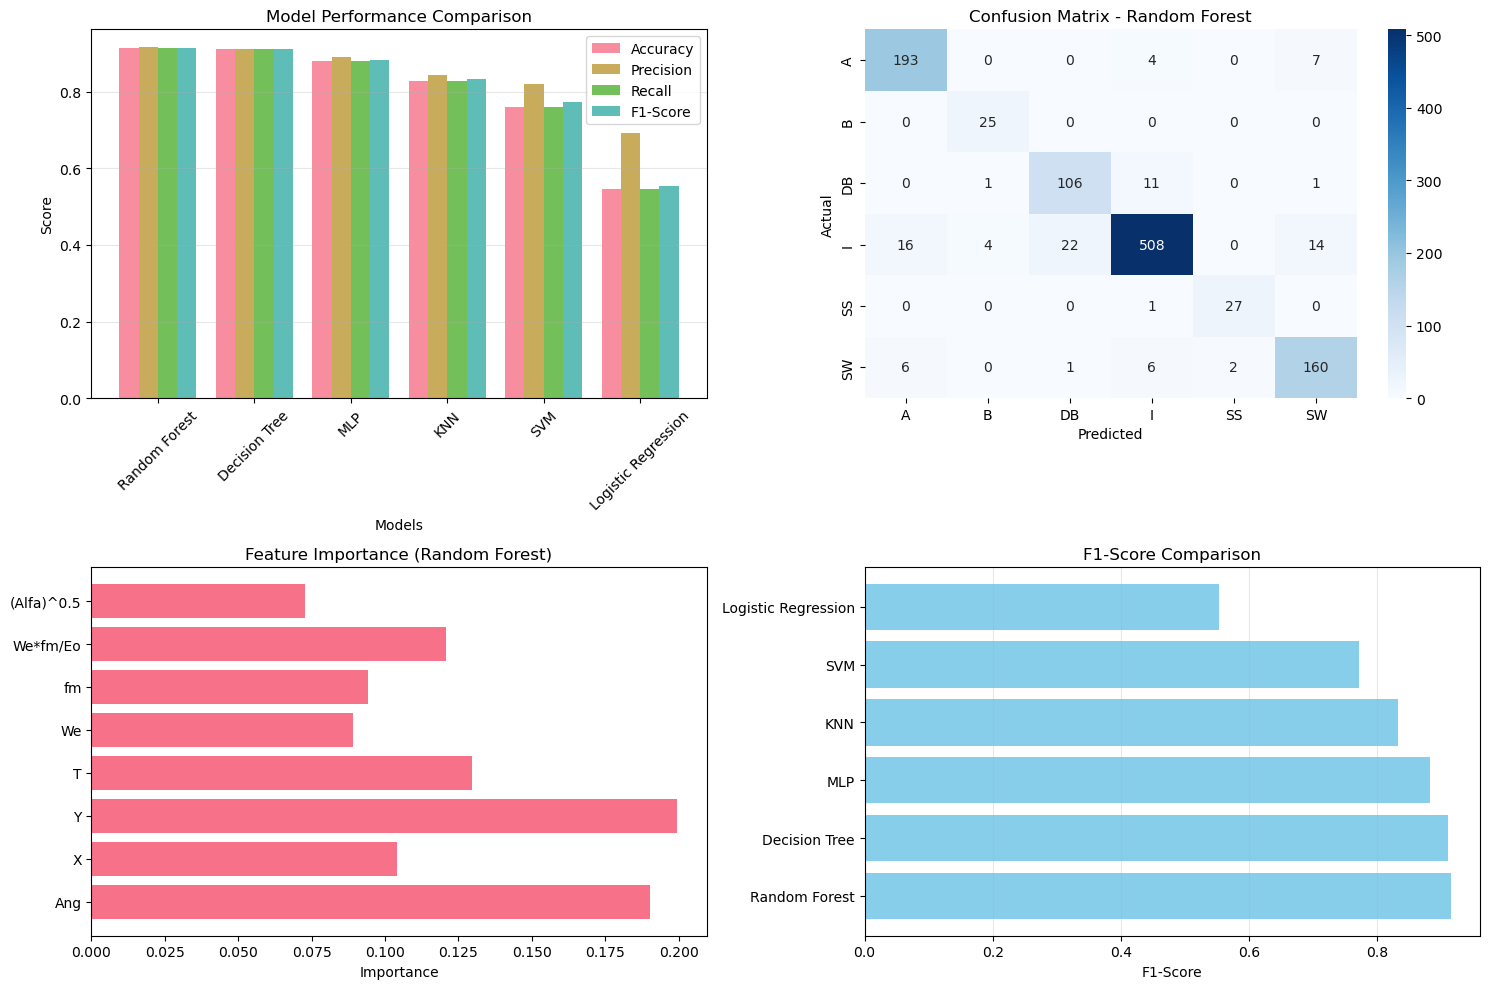



Detailed Classification Report - Random Forest:
              precision    recall  f1-score   support

           A       0.90      0.95      0.92       204
           B       0.83      1.00      0.91        25
          DB       0.82      0.89      0.85       119
           I       0.96      0.90      0.93       564
          SS       0.93      0.96      0.95        28
          SW       0.88      0.91      0.90       175

    accuracy                           0.91      1115
   macro avg       0.89      0.94      0.91      1115
weighted avg       0.92      0.91      0.91      1115



In [27]:
# Step 9: Results Comparison
print("\n\n8. RESULTS COMPARISON")
print("-" * 30)

results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'Precision': [results[model]['precision'] for model in results],
    'Recall': [results[model]['recall'] for model in results],
    'F1-Score': [results[model]['f1_score'] for model in results]
})

results_df = results_df.sort_values('F1-Score', ascending=False)
print("Model Performance Comparison:")
print(results_df.round(4))

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
x_pos = np.arange(len(results_df))
width = 0.2
plt.bar(x_pos - 1.5*width, results_df['Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x_pos - 0.5*width, results_df['Precision'], width, label='Precision', alpha=0.8)
plt.bar(x_pos + 0.5*width, results_df['Recall'], width, label='Recall', alpha=0.8)
plt.bar(x_pos + 1.5*width, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x_pos, results_df['Model'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

best_model_name = results_df.iloc[0]['Model']
best_predictions = results[best_model_name]['predictions']

plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.subplot(2, 2, 3)
if 'Random Forest' in results:
    feature_importance = results['Random Forest']['model'].feature_importances_
    plt.barh(selected_features, feature_importance)
    plt.title('Feature Importance (Random Forest)')
    plt.xlabel('Importance')
else:
    plt.text(0.5, 0.5, 'Feature importance\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Importance')


plt.subplot(2, 2, 4)
plt.barh(results_df['Model'], results_df['F1-Score'], color='skyblue')
plt.xlabel('F1-Score')
plt.title('F1-Score Comparison')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\n\nDetailed Classification Report - {best_model_name}:")
print("=" * 60)
print(classification_report(y_test, best_predictions, target_names=le.classes_))


In [34]:
print("\n\n9. CONCLUSIONS")
print("-" * 20)

print("Key Findings:")
print(f"1. Best performing model: {best_model_name}")
print(f"   - F1-Score: {results[best_model_name]['f1_score']:.4f}")
print(f"   - Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   - Best parameters: {results[best_model_name]['best_params']}")

print(f"\n2. Feature Selection:")
print(f"   - Selected {len(selected_features)} most important features")
print(f"   - Removed {len(removed_features)} less significant features")

print(f"\n3. Class Imbalance Handling:")
print(f"   - Applied SMOTE to balance training data")
print(f"   - Improved model performance on minority classes")

print(f"\n4. Model Performance Ranking:")
for i, (_, row) in enumerate(results_df.iterrows(), 1):
    print(f"   {i}. {row['Model']}: F1-Score = {row['F1-Score']:.4f}")

print(f"\n5. Recommendations:")
print(f"   - Use {best_model_name} for flow pattern prediction")
print(f"   - Focus on the {len(selected_features)} selected features")
print(f"   - Consider ensemble methods for production deployment")
print(f"   - Regular model retraining with new data recommended")




9. CONCLUSIONS
--------------------
Key Findings:
1. Best performing model: Random Forest
   - F1-Score: 0.9144
   - Accuracy: 0.9139
   - Best parameters: {'max_depth': None, 'n_estimators': 200}

2. Feature Selection:
   - Selected 8 most important features
   - Removed 5 less significant features

3. Class Imbalance Handling:
   - Applied SMOTE to balance training data
   - Improved model performance on minority classes

4. Model Performance Ranking:
   1. Random Forest: F1-Score = 0.9144
   2. Decision Tree: F1-Score = 0.9105
   3. MLP: F1-Score = 0.8818
   4. KNN: F1-Score = 0.8322
   5. SVM: F1-Score = 0.7718
   6. Logistic Regression: F1-Score = 0.5535

5. Recommendations:
   - Use Random Forest for flow pattern prediction
   - Focus on the 8 selected features
   - Consider ensemble methods for production deployment
   - Regular model retraining with new data recommended
